In [106]:
import os

# Create outputs folder if it doesn't exist
os.makedirs("../images", exist_ok=True)

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [108]:
data = pd.read_csv("../data/student_data.csv")

data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [109]:
print("Shape :", data.shape)

print("\nColumns")
print(data.columns)

print("\nInfo")
data.info()

print("\nDescription")
display(data.describe())

Shape : (6607, 20)

Columns
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5  

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [110]:
# Check Missing Values
print("Missing Values Before Cleaning:")
print(data.isnull().sum())

# Fill Categorical Missing Values using Mode
data["Teacher_Quality"] = data["Teacher_Quality"].fillna(
    data["Teacher_Quality"].mode()[0]
)

data["Parental_Education_Level"] = data["Parental_Education_Level"].fillna(
    data["Parental_Education_Level"].mode()[0]
)

data["Distance_from_Home"] = data["Distance_from_Home"].fillna(
    data["Distance_from_Home"].mode()[0]
)

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

Missing Values Before Cleaning:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Missing Values After Cleaning:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Interne

In [111]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [112]:
data.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

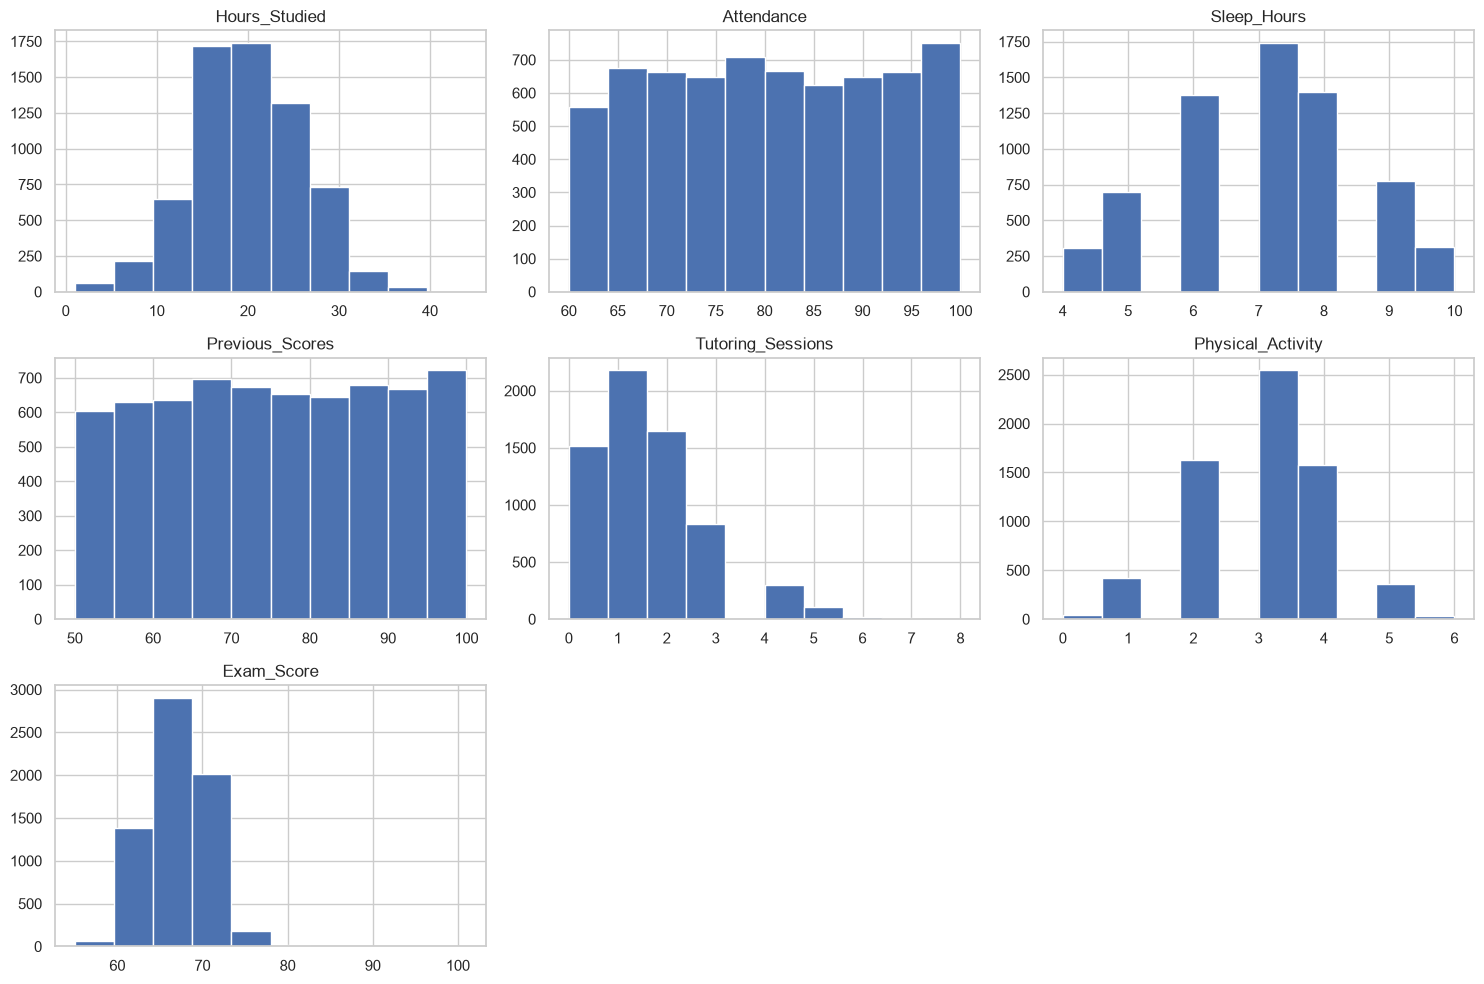

In [113]:
data.hist(figsize=(15,10))

plt.tight_layout()

plt.savefig("../images/all_histograms.png", dpi=300, bbox_inches="tight")

plt.show()

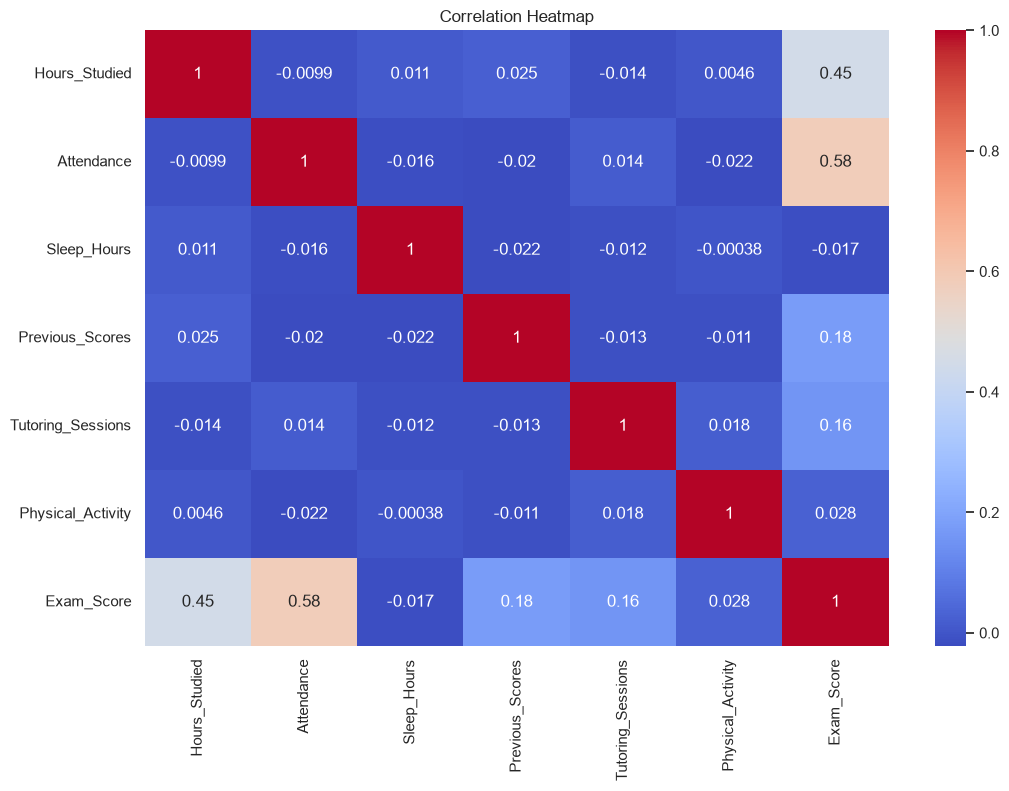

In [114]:
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

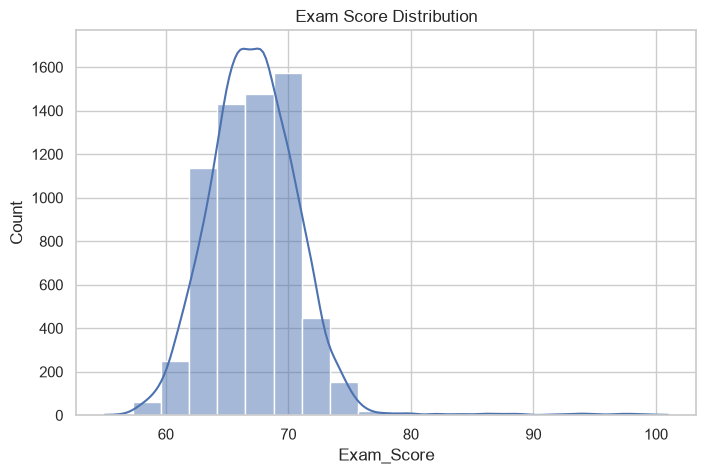

In [115]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["Exam_Score"],
    bins=20,
    kde=True
)

plt.title("Exam Score Distribution")

plt.savefig("../images/exam_score_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

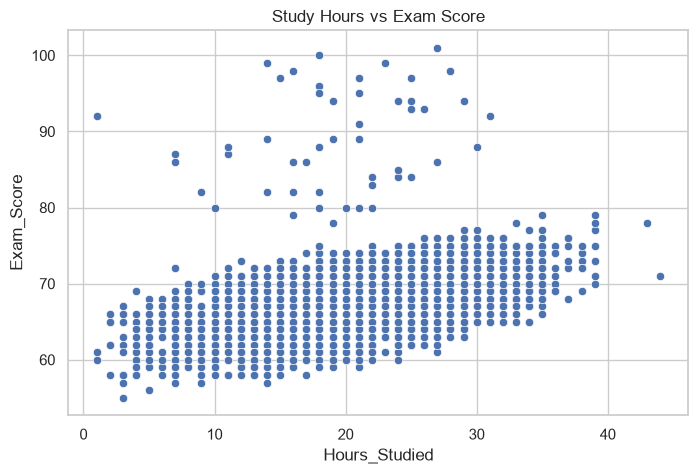

In [116]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=data
)

plt.title("Study Hours vs Exam Score")

plt.savefig("../images/study_hours_vs_exam_score.png", dpi=300, bbox_inches="tight")

plt.show()

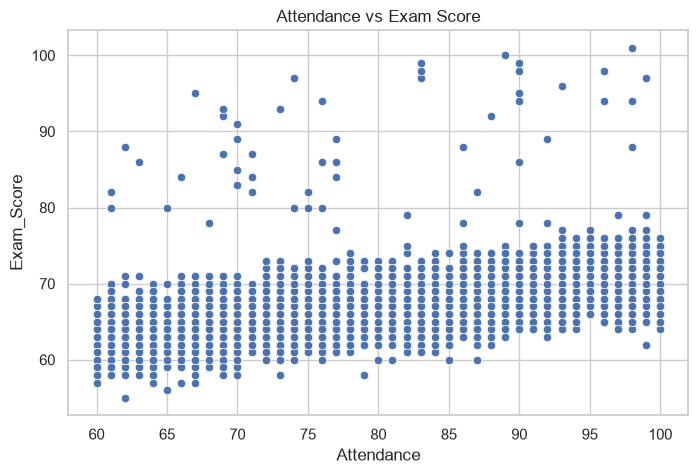

In [117]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Attendance",
    y="Exam_Score",
    data=data
)

plt.title("Attendance vs Exam Score")

plt.savefig("../images/attendance_vs_exam_score.png", dpi=300, bbox_inches="tight")

plt.show()

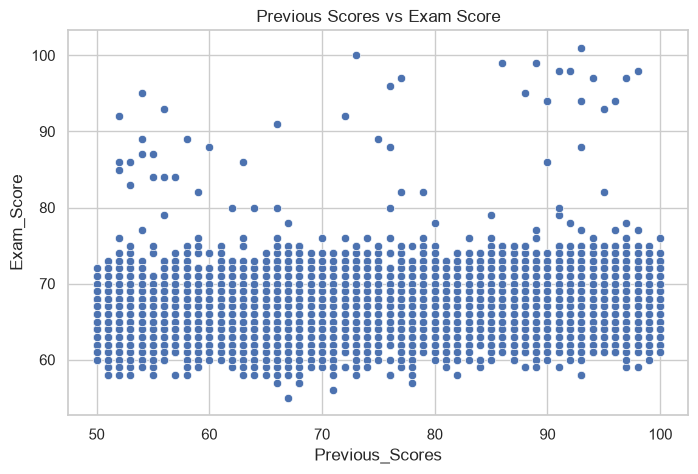

In [118]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Previous_Scores",
    y="Exam_Score",
    data=data
)

plt.title("Previous Scores vs Exam Score")

plt.savefig("../images/previous_scores_vs_exam_score.png", dpi=300, bbox_inches="tight")

plt.show()

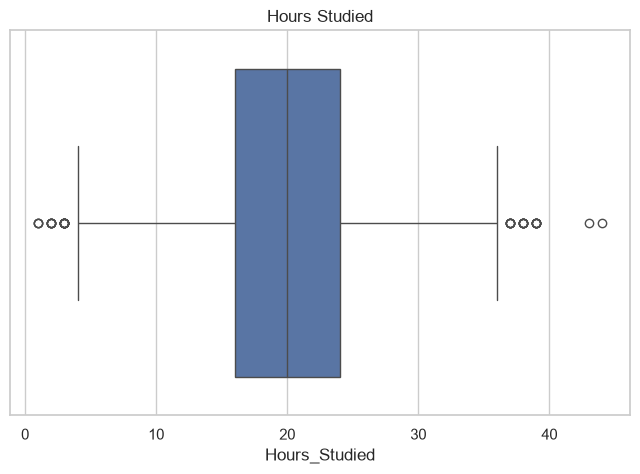

In [119]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=data["Hours_Studied"]
)

plt.title("Hours Studied")

plt.savefig("../images/hours_studied_boxplot.png", dpi=300, bbox_inches="tight")

plt.show()

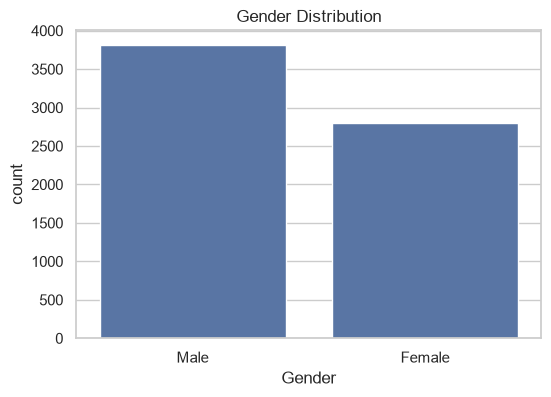

In [120]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    data=data
)

plt.title("Gender Distribution")

plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

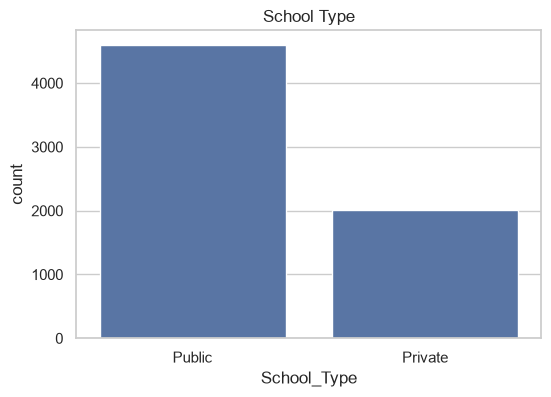

In [121]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="School_Type",
    data=data
)

plt.title("School Type")

plt.savefig("../images/school_type_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

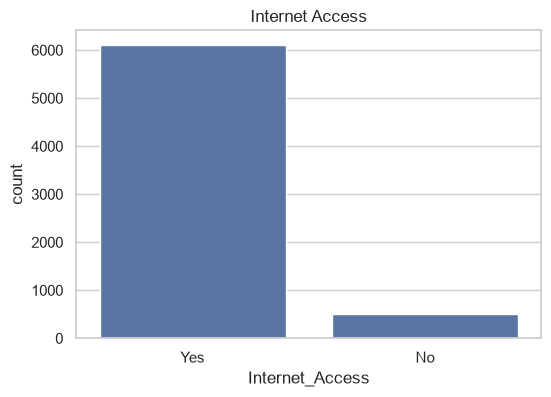

In [122]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Internet_Access",
    data=data
)

plt.title("Internet Access")

plt.savefig("../images/internet_access_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

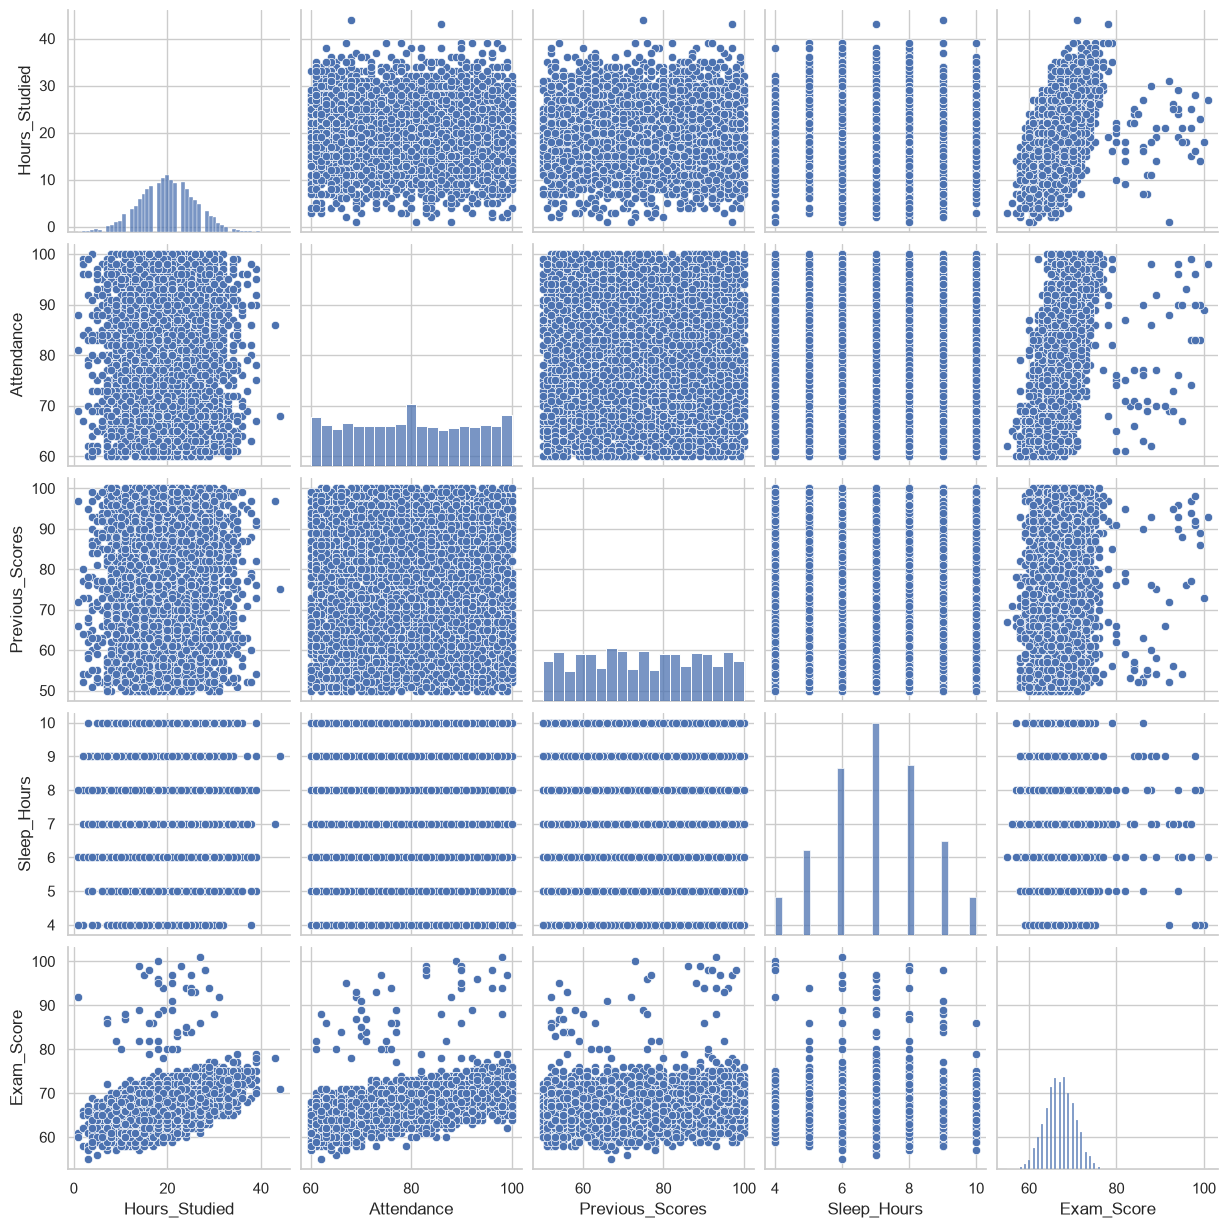

In [123]:
sns.pairplot(
    data[
        [
            "Hours_Studied",
            "Attendance",
            "Previous_Scores",
            "Sleep_Hours",
            "Exam_Score"
        ]
    ]
)

plt.savefig("../images/pairplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [124]:
def performance(score):

    if score < 60:
        return "Poor"

    elif score < 80:
        return "Average"

    else:
        return "Excellent"


data["Performance"] = data["Exam_Score"].apply(performance)

data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Average
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Average
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Average
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Average
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,Average


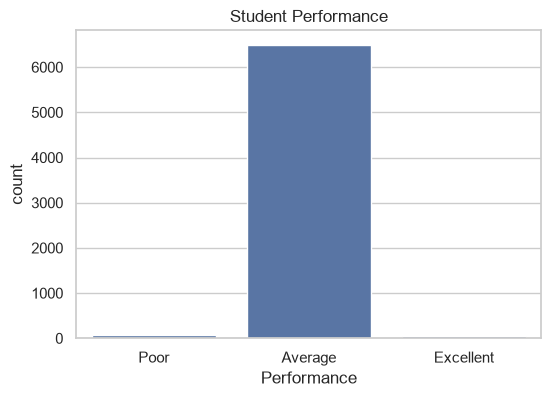

In [125]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Performance",
    data=data,
    order=["Poor", "Average", "Excellent"]
)

plt.title("Student Performance")

plt.savefig("../images/student_performance_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [126]:
data.to_csv("../data/student_cleaned.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
